# HT6 — Task 2: competencia entre plataformas (grupo 4)

Grupo $g=4$, conjunto 4: $r_1=1$, $r_2=0.8$, $\alpha_{12}=1.5$, $\alpha_{21}=0.6$. 
El campo es
\(\dot x=x(1-x-1.5y),\qquad \dot y=0.8y(1-y-0.6x).\)

Predicciones originales del Task 1.3(c), conservadas sin modificaciones: P1, P2, P3 y P4 convergen a $(0,1)$. Según el Task 1, $(0,0)$ es fuente, $(1,0)$ es silla, y $(0,1)$ es nodo estable con valores propios $-0.5,-0.8$. Tiempo de recuperación esperado: $2$ unidades. Semilla reproducible: 20261008. Todas las figuras y resultados se generan al ejecutar las celdas en orden.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

SEED = 20261008
np.random.seed(SEED)
P = {'P1': (0.05, 0.05), 'P2': (0.8, 0.3),
     'P3': (0.3, 0.8), 'P4': (0.6, 0.6)}
EQ = {'fuente': np.array([0., 0.]), 'silla': np.array([1., 0.]),
      'nodo estable': np.array([0., 1.])}

def campo(t, z, a12=1.5, a21=0.6):
    z = np.asarray(z)
    x, y = z[..., 0], z[..., 1]
    return np.stack((x*(1-x-a12*y), 0.8*y*(1-y-a21*x)), axis=-1)

def integrar(f, z0, h, T, metodo):
    """Integración propia; f(t,z), z0, h, T. Último paso truncado a T."""
    if h <= 0 or T < 0:
        raise ValueError('Se requiere h > 0 y T >= 0')
    t = 0.0
    z = np.array(z0, dtype=float, copy=True)
    tiempos, estados = [t], [z.copy()]
    while t < T - 1e-12:
        dt = min(h, T-t)
        if metodo == 'Euler':
            z = z + dt*f(t, z)
        elif metodo == 'RK4':
            k1 = f(t, z)
            k2 = f(t+dt/2, z+dt*k1/2)
            k3 = f(t+dt/2, z+dt*k2/2)
            k4 = f(t+dt, z+dt*k3)
            z = z + dt*(k1+2*k2+2*k3+k4)/6
        else:
            raise ValueError('Método desconocido')
        t = min(t+dt, T)
        tiempos.append(t)
        estados.append(z.copy())
    return np.array(tiempos), np.stack(estados)

def euler(f, z0, h, T):
    return integrar(f, z0, h, T, 'Euler')

def rk4(f, z0, h, T):
    return integrar(f, z0, h, T, 'RK4')

## Task 2.1 — Error y orden de integración

Se mide el error global $|z_h(10)-z_\mathrm{ref}(10)|_2$ para P2. solve_ivp se usa solo aquí como referencia, con DOP853 y tolerancias absolutas y relativas de $10^{-12}$. La pendiente se obtiene con regresión lineal de $\log(\mathrm{error})$ sobre $\log(h)$.

Referencia DOP853 en T=10: [0.03460784 0.95186194]
     h       error Euler         error RK4
  0.2000    4.129207659e-03    2.672136689e-08
  0.1000    2.056208233e-03    1.654643214e-09
  0.0500    1.026097686e-03    1.028891449e-10
  0.0250    5.125579898e-04    6.358618592e-12
  0.0125    2.561575799e-04    3.392282535e-13
Euler: pendiente estimada=1.0026, orden teórico=1
RK4: pendiente estimada=4.0554, orden teórico=4


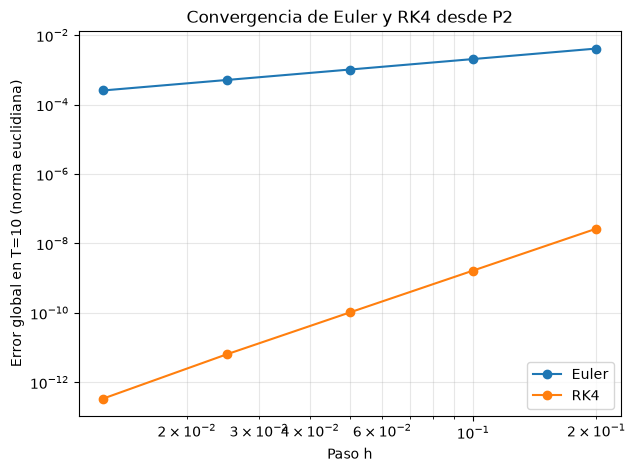

In [2]:
hs = np.array([0.2, 0.1, 0.05, 0.025, 0.0125])
ref = solve_ivp(campo, (0,10), P['P2'], method='DOP853', atol=1e-12,
                rtol=1e-12).y[:, -1]
errores = {}
for nombre, solver in [('Euler', euler), ('RK4', rk4)]:
    errores[nombre] = np.array([np.linalg.norm(solver(campo, P['P2'], h, 10)[1][-1]-ref)
                                for h in hs])
print('Referencia DOP853 en T=10:', ref)
print('     h       error Euler         error RK4')
for h, e1, e4 in zip(hs, errores['Euler'], errores['RK4']):
    print(f'{h:8.4f}   {e1:16.9e}   {e4:16.9e}')
for nombre, teorico in [('Euler',1), ('RK4',4)]:
    pendiente = np.polyfit(np.log(hs), np.log(errores[nombre]), 1)[0]
    print(f'{nombre}: pendiente estimada={pendiente:.4f}, orden teórico={teorico}')
fig, ax = plt.subplots(figsize=(7,5))
for nombre in errores:
    ax.loglog(hs, errores[nombre], 'o-', label=nombre)
ax.set(xlabel='Paso h', ylabel='Error global en T=10 (norma euclidiana)',
       title='Convergencia de Euler y RK4 desde P2')
ax.grid(True, which='both', alpha=.3); ax.legend(); plt.show()

Euler tiene error global de orden 1 y RK4 de orden 4: al dividir $h$ entre 2, se espera un factor cercano a 2 y 16, respectivamente. Pequeñas diferencias en las pendientes se deben a términos de orden superior, precisión finita y error no nulo de la referencia.

## Task 2.2 — Retrato de fases y contraste con las predicciones

Los ejes son nulclinas invariantes; también se trazan $y=(1-x)/1.5$ y $y=1-0.6x$ donde quedan dentro de la figura. Las flechas se normalizan solo para visualizar la dirección. Hay 16 trayectorias adicionales, incluidas varias cerca de ambos ejes.

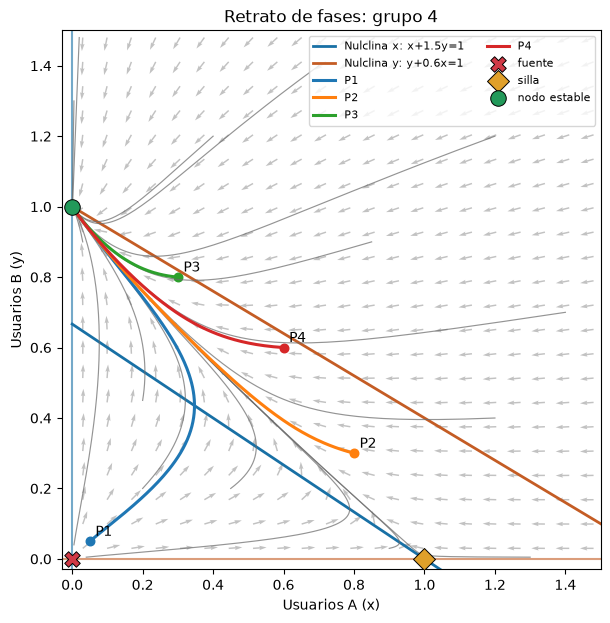

Predicción original | simulación en T=35 | distancia al equilibrio (0,1)
P1 -> (0,1) | [2.8000000e-07 9.9999956e-01] | 5.225e-07
P2 -> (0,1) | [1.4000000e-07 9.9999978e-01] | 2.650e-07
P3 -> (0,1) | [1.0000000e-08 9.9999998e-01] | 2.020e-08
P4 -> (0,1) | [3.0000000e-08 9.9999995e-01] | 6.358e-08


In [3]:
fig, ax = plt.subplots(figsize=(8,7))
xx, yy = np.meshgrid(np.linspace(.03,1.48,22), np.linspace(.03,1.48,22))
v = campo(0, np.stack((xx,yy),axis=-1))
mag = np.hypot(v[...,0],v[...,1])
ax.quiver(xx, yy, v[...,0]/mag, v[...,1]/mag, color='0.7', alpha=.8)
X = np.linspace(0,1.5,400)
ax.plot(X, (1-X)/1.5, color='#1870a5', lw=2, label='Nulclina x: x+1.5y=1')
ax.plot(X, 1-.6*X, color='#c45c24', lw=2, label='Nulclina y: y+0.6x=1')
ax.axvline(0, color='#1870a5', alpha=.6)
ax.axhline(0, color='#c45c24', alpha=.6)
extras = [(0.005,.04),(.005,1.3),(.04,.005),(1.3,.005),
          (.03,.9),(.9,.03),(.2,.2),(.45,.2),(.2,.45),(.85,.9),
          (1.2,1.2),(.4,1.2),(1.2,.4),(.7,1.4),(1.4,.7),(.02,1.48)]
for z0 in extras:
    _, z = rk4(campo, z0, .05, 35)
    ax.plot(z[:,0],z[:,1], color='0.42', lw=.85, alpha=.72)
for etiqueta, z0 in P.items():
    _, z = rk4(campo, z0, .05, 35)
    linea, = ax.plot(z[:,0],z[:,1], lw=2.2, label=etiqueta)
    ax.scatter(*z0, color=linea.get_color(), s=38)
    ax.annotate(etiqueta, z0, xytext=(4,4), textcoords='offset points')
for nombre, pt, color, marker in [('fuente',(0,0),'#d03946','X'),
                                  ('silla',(1,0),'#e0a02a','D'),
                                  ('nodo estable',(0,1),'#22995a','o')]:
    ax.scatter(*pt, s=125, color=color, marker=marker, edgecolor='black',
               linewidth=.7, zorder=10, label=nombre)
ax.set(xlim=(-.03,1.5), ylim=(-.03,1.5), xlabel='Usuarios A (x)',
       ylabel='Usuarios B (y)', title='Retrato de fases: grupo 4')
ax.set_aspect('equal'); ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.show()
print('Predicción original | simulación en T=35 | distancia al equilibrio (0,1)')
for etiqueta, z0 in P.items():
    fin = rk4(campo, z0, .05, 35)[1][-1]
    print(etiqueta, '-> (0,1) |', np.round(fin, 8), '|',
          f'{np.linalg.norm(fin-[0,1]):.3e}')

Comparación 2.2(c). Las cuatro predicciones originales fueron $(0,1)$; las cuatro simulaciones se aproximan a ese punto. No hay discrepancias. La predicción menos inmediata fue P1: comienza bajo ambas rectas, donde crecen $x$ e $y$, por lo que su movimiento inicial no parece apuntar a la exclusión de A. Acertó porque la nulclina de $x$ queda debajo de la de $y$ en el cuadrante: al crecer, la trayectoria entra en una región donde $x$ disminuye e $y$ aumenta; además $(1,0)$ es una silla y $(0,1)$ el único nodo estable accesible desde el interior.

## Task 2.3 — Cuencas de atracción

Se simulan los 3600 estados de la malla mediante RK4 propio, vectorizado, hasta alcanzar $|z-(0,1)|_2<10^{-6}$ y $|f(z)|_2<10^{-6}$, o hasta $T=100$. El doble criterio comprueba cercanía al equilibrio y cambio temporal pequeño. Se registra cuántos estados quedan sin clasificar; cualquier proporción se calcula solo tras verificar que no quede ninguno. La fracción es respecto a la malla finita del cuadrado $0.01,1.5^2$, no respecto a todo el cuadrante no acotado.

Puntos en la cuenca de (0,1): 3600 / 3600
Sin clasificar: 0 Tiempo máximo efectivo: 44.2
Fracción en el cuadrado muestreado: (0,1) = 1.0


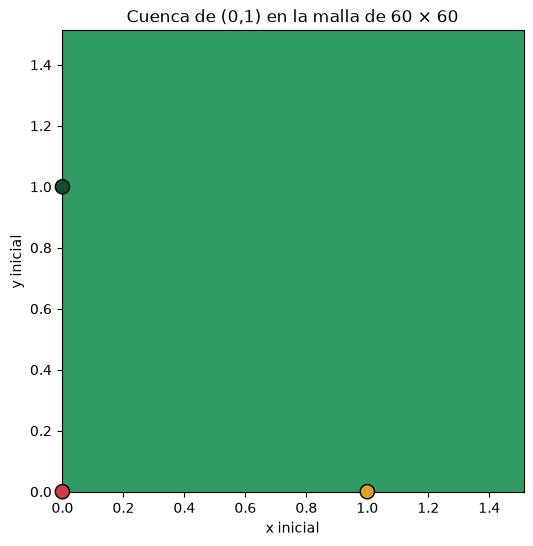

In [4]:
eje = np.linspace(.01,1.5,60)
MX, MY = np.meshgrid(eje,eje)
z = np.stack((MX, MY),axis=-1)
destino = np.array([0.,1.])
Tmax, h = 100., .1
convergio = np.zeros((60,60), dtype=bool)
pasos = np.full((60,60), np.nan)
for n in range(1,round(Tmax/h)+1):
    k1=campo(0,z)
    k2=campo(0,z+h*k1/2)
    k3=campo(0,z+h*k2/2)
    k4=campo(0,z+h*k3)
    z = z + h*(k1+2*k2+2*k3+k4)/6
    nuevo = (~convergio) & (np.linalg.norm(z-destino,axis=-1)<1e-6) & \
            (np.linalg.norm(campo(0,z),axis=-1)<1e-6)
    pasos[nuevo] = n
    convergio |= nuevo
    if convergio.all():
        break
print('Puntos en la cuenca de (0,1):', convergio.sum(), '/ 3600')
print('Sin clasificar:', (~convergio).sum(), 'Tiempo máximo efectivo:',n*h)
assert convergio.all(), 'Aumentar Tmax antes de interpretar fracciones'
print('Fracción en el cuadrado muestreado: (0,1) =',convergio.mean())
fig,ax=plt.subplots(figsize=(7,6))
from matplotlib.colors import ListedColormap
ax.pcolormesh(MX,MY,convergio.astype(int), shading='nearest',
              cmap=ListedColormap(['#cccccc','#309b62']),vmin=0,vmax=1)
ax.scatter([0,1,0],[0,0,1],c=['#d03946','#e0a02a','#154b30'],
           s=105,edgecolor='black',clip_on=False,zorder=3)
ax.set(xlabel='x inicial',ylabel='y inicial',
       title='Cuenca de (0,1) en la malla de 60 × 60')
ax.set_aspect('equal');plt.show()

Interpretación 2.3(d). Toda la malla estrictamente positiva pertenece a la cuenca de $(0,1)$ (100 % de los puntos muestreados). El eje $y=0$ es invariante y conduce a $(1,0)$ para $x>0$; es la variedad estable de la silla y no forma parte de la malla, que comienza en $y=0.01$. El eje $x=0$ es invariante y conduce a $(0,1)$ para $y>0$. Por eso una sola cuenca llena el interior y no corresponde hacer la bisección del inciso 2.3(c). El resultado no atribuye un área relativa a todo el cuadrante infinito.

## Task 2.4 — Recuperación y estabilidad de Euler

En $(0,1)$, la restricción de factibilidad local es $\delta x\geq0$ y $1+\delta y\geq0$: geométricamente hay medio plano disponible. Para ajustarse a la indicación de ocho direcciones dentro de un cuarto de plano, se toman ocho ángulos espaciados en $0,\pi/2$, que satisfacen ambas restricciones. La última dirección es tangente al eje $x=0$ y tiene tasa asintótica $0.8$; para $\delta x>0$ la tasa lenta es $0.5$. Por tanto, no sería correcto forzar una coincidencia de las ocho tasas con $0.5$.

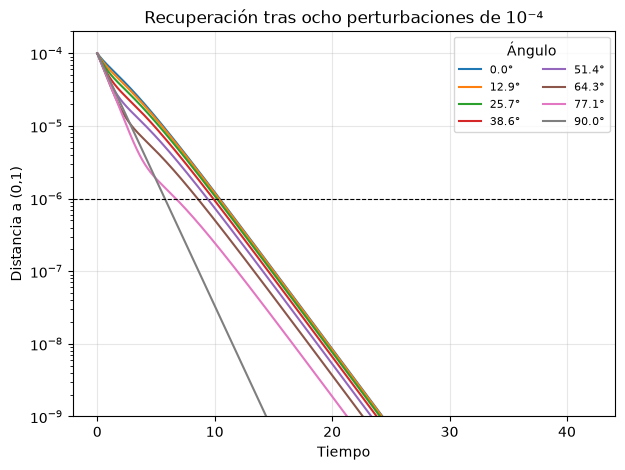

Dirección | ángulo | tasa ventana | tasa teórica | error relativo | tasa tardía (25–35)
   1 |    0.0° | 0.441354 | 0.500 | 11.729% | 0.499969
   2 |   12.9° | 0.436671 | 0.500 | 12.666% | 0.499963
   3 |   25.7° | 0.433715 | 0.500 | 13.257% | 0.499957
   4 |   38.6° | 0.434223 | 0.500 | 13.155% | 0.499948
   5 |   51.4° | 0.444310 | 0.500 | 11.138% | 0.499943
   6 |   64.3° | 0.487154 | 0.500 | 2.569% | 0.499925
   7 |   77.1° | 0.708821 | 0.500 | 41.764% | 0.499873
   8 |   90.0° | 0.800013 | 0.800 | 0.002% | nan


In [5]:
equilibrio = np.array([0.,1.])
angulos=np.linspace(0,np.pi/2,8)
registro=[]
fig,ax=plt.subplots(figsize=(7,5))
for i,ang in enumerate(angulos):
    direccion=np.array([np.cos(ang),np.sin(ang)])
    if i==7: direccion=np.array([0.,1.])  
    t,tray=rk4(campo,equilibrio+1e-4*direccion,.025,42)
    norma=np.linalg.norm(tray-equilibrio,axis=1)
    mascara=(norma<1e-4*(1+1e-9)) & (norma>=1e-6)
    tasa=-np.polyfit(t[mascara],np.log(norma[mascara]),1)[0]
    tasa_tardia = (-np.polyfit(t[(t>=25)&(t<=35)],
                               np.log(norma[(t>=25)&(t<=35)]),1)[0]
                   if i<7 else np.nan)
    teorica=.8 if i==7 else .5
    error_rel=abs(tasa-teorica)/teorica
    registro.append((i+1,ang,tasa,teorica,error_rel,tasa_tardia))
    ax.semilogy(t,norma,label=f'{np.degrees(ang):.1f}°')
ax.axhline(1e-6,color='black',ls='--',lw=.8)
ax.set(xlabel='Tiempo',ylabel='Distancia a (0,1)',ylim=(1e-9,2e-4),
       title='Recuperación tras ocho perturbaciones de 10⁻⁴')
ax.legend(title='Ángulo',ncol=2,fontsize=8);ax.grid(alpha=.3);plt.show()
print('Dirección | ángulo | tasa ventana | tasa teórica | error relativo | tasa tardía (25–35)')
for fila in registro:
    print(f'{fila[0]:4d} | {np.degrees(fila[1]):6.1f}° | {fila[2]:.6f} |'
          f' {fila[3]:.3f} | {100*fila[4]:.3f}% | {fila[5]:.6f}')

Interpretación 2.4(a,b). La tasa local lenta predicha por el Task 1.2 es $\min|\Re(\lambda)|=0.5$. Las direcciones que tienen componente $x>0$ se aproximan a esa tasa más tarde (columna 25–35); durante la ventana pedida de dos órdenes de magnitud, algunas aún mezclan los dos modos y tienen un error relativo visible. Incluso aparecen pendientes inferiores a $0.5$ en esa ventana, porque la jacobiana acopla las componentes y la norma euclidiana no tiene por qué decaer a una tasa instantánea igual a uno de los valores propios. La dirección $x=0$ nunca activa el modo lento: el eje es invariante y su decaimiento verdadero es $0.8$ (comparar esa fila con 0.8). La estimación tardía de ese caso se omite porque a esos tiempos la distancia cae cerca de la precisión de máquina. Una dirección exactamente alineada con un modo rápido es una excepción a la afirmación de que todas acaban con la tasa lenta.

Derivación manual 2.4(c). Para un valor propio $\lambda=a+ib$, Euler linealiza como $u_{n+1}=(1+h\lambda)u_n$. Pedir $|1+h\lambda|<1$ equivale a $(1+ha)^2+h^2b^2<1$, o $2ha+h^2|\lambda|^2<0$. Con $h>0$ y $a<0$: $0<h<-2a/|\lambda|^2$. Para $\lambda=-0.5$, $h_{\max}=4$; para $\lambda=-0.8$, $h_{\max}=2.5$. Convergencia lineal exige $h<2.5$; en $h=2.5$ hay un multiplicador $-1$ y no se satisface la desigualdad estricta.

In [6]:
z_cerca=np.array([1e-5,1+1e-5])
def converge_euler(h, nmax=15000, tol=2e-6):
    z=z_cerca.copy()
    ultimos=[]
    for k in range(nmax):
        with np.errstate(over='ignore',invalid='ignore'):
            z=z+h*campo(0,z)
        if not np.all(np.isfinite(z)) or np.max(np.abs(z))>1e8:
            return False
        if k>=nmax-100:
            ultimos.append(z.copy())
    a=np.array(ultimos)
    return (np.max(np.linalg.norm(a-equilibrio,axis=1))<tol and
            np.max(np.linalg.norm(campo(0,a),axis=1))<tol)

izq,der=2.0,2.7
assert converge_euler(izq) and not converge_euler(der)
for _ in range(16):
    medio=(izq+der)/2
    if converge_euler(medio): izq=medio
    else: der=medio
print(f'Intervalo numérico del paso máximo práctico: [{izq:.7f}, {der:.7f}]')
print('Umbral lineal:', 2.5)

Intervalo numérico del paso máximo práctico: [2.4997818, 2.4997925]
Umbral lineal: 2.5


Interpretación 2.4(d). El intervalo de bisección es un umbral práctico para la tolerancia, el estado y los 15000 pasos elegidos. Muy cerca de $h=2.5$, el multiplicador de $-0.8$ se aproxima a $-1$ y la convergencia es lenta; eso puede desplazar el umbral medido respecto al límite teórico estricto. Además, Euler aplicado al campo no lineal puede mostrar oscilaciones o ciclos para pasos grandes: la linealización predice estabilidad local, no la dinámica global de pasos grandes. El valor $2.5$ se obtiene exactamente de los valores propios, no de la bisección.

## Task 2.5 — Campaña frente a diferenciación

Desde P2 ambas plataformas comienzan con usuarios y A es la que acaba con menos: su base tiende a cero. Una campaña para A sustituye $x_0=0.8$ por $0.8+\Delta$ manteniendo $y_0=0.3$. Para cualquier $\Delta>0$ finito, el punto permanece en el interior positivo, que pertenece a la cuenca de $(0,1)$. La única vía de llegar a $(1,0)$ es comenzar exactamente en el eje invariante $y=0$, algo que sumar usuarios a A no hace. Así, no existe un $\Delta$ mínimo que cambie el destino y no procede una bisección para 2.5(a).

Campaña Δ=0: z(T=80)=[0. 1.]
Campaña Δ=0.5: z(T=80)=[0. 1.]
Campaña Δ=2: z(T=80)=[0. 1.]
Campaña Δ=10: z(T=80)=[0. 1.]


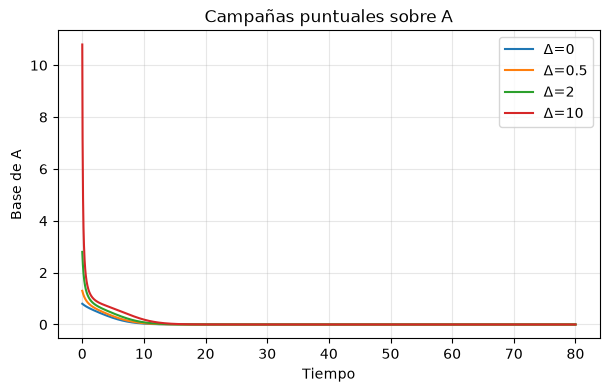

In [7]:
fig,ax=plt.subplots(figsize=(7,4))
for delta in (0, .5, 2, 10):
    t,z=rk4(campo,(.8+delta,.3),.025,80)
    ax.plot(t,z[:,0],label=f'Δ={delta:g}')
    print(f'Campaña Δ={delta:g}: z(T=80)={np.round(z[-1],8)}')
ax.set(xlabel='Tiempo',ylabel='Base de A',title='Campañas puntuales sobre A')
ax.legend();ax.grid(alpha=.3);plt.show()

Umbral analítico 2.5(b). Diferenciar A reduce $\alpha_{12}$, el coeficiente que mide cuánto B frena a A, y conserva $\alpha_{21}=0.6$. En $(0,1)$ el valor propio de invasión de A es $\lambda_A=r_1(1-\alpha_{12})=1-\alpha_{12}$. Cambia de signo cuando $\boxed{\alpha_{12}^{\rm crit}=1}$. Por encima de 1 A no invade y B excluye a A; por debajo de 1, ambos coeficientes son menores que 1 y surge coexistencia interior estable. En el umbral $\lambda_A=0$, la clasificación hiperbólica no basta para decidir por sí sola el comportamiento: se verifica a ambos lados.

α12=0.8: fin=[0.38461538 0.76923077], equilibrio predicho=[0.38461538 0.76923077], distancia=3.771e-15
α12=1.2: fin=[2.28350322e-22 1.00000000e+00], equilibrio predicho=[0. 1.], distancia=6.661e-16


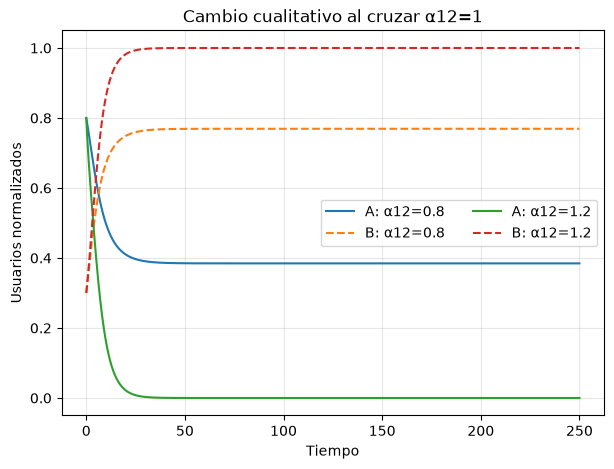

In [8]:
fig,ax=plt.subplots(figsize=(7,5))
for a12 in (.8,1.2):
    f=lambda t,z,a=a12: campo(t,z,a12=a)
    t,z=rk4(f,P['P2'],.1,250)
    if a12<1:
        esperado=np.array([(1-a12)/(1-a12*.6),(.4)/(1-a12*.6)])
    else:
        esperado=np.array([0.,1.])
    print(f'α12={a12}: fin={z[-1]}, equilibrio predicho={esperado}, '
          f'distancia={np.linalg.norm(z[-1]-esperado):.3e}')
    ax.plot(t,z[:,0],label=f'A: α12={a12}')
    ax.plot(t,z[:,1],'--',label=f'B: α12={a12}')
ax.set(xlabel='Tiempo',ylabel='Usuarios normalizados',
       title='Cambio cualitativo al cruzar α12=1')
ax.legend(ncol=2);ax.grid(alpha=.3);plt.show()

Recomendación 2.5(c). Elegir la diferenciación de A y llevar $\alpha_{12}$ suficientemente por debajo de 1 (por ejemplo 0.8), porque cambia el régimen a coexistencia; la campaña puntual no cambia el equilibrio final para ninguna adición finita de usuarios a A desde P2. Una reducción apenas inferior a 1 sería poco robusta ante un error de estimación: la tasa de recuperación se acerca a cero al aproximarse el valor propio al eje imaginario y el tiempo de recuperación crece mucho. Conviene dejar margen respecto de $\alpha_{12}=1$ y comprobar la velocidad de recuperación con los valores propios del nuevo equilibrio.